In [ ]:
import cv2
import numpy as np
from joblib import Parallel, delayed
from functools import partial

class PreprocessBatch():
    def __init__(self, height_ratio=0.10, lower_thresh=5, upper_thresh=60, pixel_thresh=0.5,
                 clip_limit=2.0, tile_grid_size=(4, 4), resize_ratio=4, target_size=1824, n_jobs=-1):
        self.height_ratio = height_ratio
        self.lower_thresh = lower_thresh
        self.upper_thresh = upper_thresh
        self.pixel_thresh = pixel_thresh
        self.n_jobs = n_jobs
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        self.resize_ratio = resize_ratio
        self.target_size = target_size
        
    def _has_subtitle(self, region):
        h, w = region.shape[:2]
        mask = cv2.inRange(region, np.array(self.lower_thresh), np.array(self.upper_thresh))
        count = cv2.countNonZero(mask)
        num_pixel_thresh = h * w * self.pixel_thresh
        return count > num_pixel_thresh

    def check_image(self, image):
        if len(image.shape) == 2:
            gray = image.copy()
            img_origin = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        elif len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
            img_origin = image.copy()
        else:
            raise ValueError("Unsupported image format!")

        gray = cv2.resize(gray, None, fx=self.resize_ratio, fy=self.resize_ratio, interpolation=cv2.INTER_CUBIC)
        img_origin = cv2.resize(img_origin, None, fx=self.resize_ratio, fy=self.resize_ratio, interpolation=cv2.INTER_CUBIC)
        
        return gray, img_origin
        
    def process_one(self, image):
        gray, img_origin = self.check_image(image)
        h, w = gray.shape[:2]
        y_start = int(h * (1 - self.height_ratio))
        y_end = y_start + int(h*0.06)
        subtitle_region = gray[y_start:y_end, :]
        
        # Tăng độ tương phản
        # clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        # lab = cv2.cvtColor(img_origin, cv2.COLOR_RGB2Lab)
        # l, a, b = cv2.split(lab)
        # l_clahe = clahe.apply(l)
        
        blur = cv2.GaussianBlur(img_origin, (5,5), 0)
        # unsharp mask
        sharp = cv2.addWeighted(img_origin, 1.7, blur, -0.7, 0)
        
        # # Kiểm tra vùng phụ đề
        if self._has_subtitle(subtitle_region):
            sharp[y_start:y_end, :] = 0

        if self.target_size < max(h, w):
            ratio = self.target_size / max(h , w)
            new_w, new_h = int(w * ratio), int(h * ratio)
            resized_img = cv2.resize(sharp, (new_w, new_h), interpolation=cv2.INTER_AREA)
            return resized_img, resized_img
        else:
            return sharp, sharp
        # return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB), img_origin
        
    def __call__(self, images):
        if self.n_jobs == 1:
            processed_imgs = [self.process_one(img) for img in images]
        else:
            processed_imgs = Parallel(n_jobs = self.n_jobs)(
                delayed(self.process_one)(img) for img in images
            )
        imgs_to_det = [img[0] for img in processed_imgs]
        imgs_origin = [img[1] for img in processed_imgs]
        return imgs_to_det, imgs_origin

proc_batch = PreprocessBatch()
custom_setting = {
    'link_threshold': 0.7,
    'text_threshold': 0.5,
    'low_text': 0.3,
    'canvas_size': 1824,
    'mag_ratio': 1.
}

In [2]:
!git clone https://github.com/huutrank4ds/Craft-parseq.git
import sys
sys.path.append('/kaggle/working/Craft-parseq')

Cloning into 'Craft-parseq'...
remote: Enumerating objects: 145, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 145 (delta 79), reused 85 (delta 38), pack-reused 17 (from 2)
Receiving objects: 100% (145/145), 75.35 MiB | 36.38 MiB/s, done.
Resolving deltas: 100% (79/79), done.


In [ ]:
from nahocr import NaHOCR
pipe = NaHOCR(device='cuda')

Downloading: "https://github.com/baudm/parseq/zipball/main" to /root/.cache/torch/hub/main.zip
/usr/local/lib/python3.11/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
Downloading: "https://github.com/baudm/parseq/releases/download/v1.0.0/parseq-bb5792a6.pt" to /root/.cache/torch/hub/checkpoints/parseq-bb5792a6.pt
100%|██████████| 91.0M/91.0M [00:00<00:00, 183MB/s]


In [4]:
import json
import os
from tqdm import tqdm
import re
import unicodedata

def create_batch(video_path, batch_size=100):
    frame_paths = [
        os.path.join(video_path, f)
        for f in os.listdir(video_path)
        if os.path.isfile(os.path.join(video_path, f))
    ]
    total_steps = (len(frame_paths) + batch_size - 1) // batch_size
    def gen():
        for i in range(0, len(frame_paths), batch_size):
            yield frame_paths[i:i+batch_size]
    return total_steps, gen()

def normalize_text(frame_text):
    """
    Hàm chuẩn hóa văn bản tiếng Việt:
    1. Chuyển thành chữ thường.
    2. Xóa tất cả dấu thanh (diacritics).
    3. Xóa tất cả các ký tự không phải là chữ cái hoặc số.
    
    Args:
        text (str): Chuỗi văn bản đầu vào.
        
    Returns:
        str: Chuỗi văn bản đã được chuẩn hóa.
    """
    # 1. Chuyển thành chữ thường
    text = ' '.join(frame_text)
    text = text.lower()
    
    # 2. Xóa dấu Unicode (diacritics)
    # Sử dụng chuẩn NFD (Normalization Form D) để tách ký tự và dấu
    # Ví dụ: 'á' -> 'a' + '´'
    text = unicodedata.normalize('NFD', text)
    # Chỉ giữ lại các ký tự cơ sở (không phải dấu)
    # 'Mn' là category của các ký tự dấu (Nonspacing Mark)
    text = ''.join([char for char in text if unicodedata.category(char) != 'Mn'])
    
    # Xử lý riêng cho chữ 'đ' vì normalize không xử lý được
    text = text.replace('đ', 'd')
    
    # 3. Xóa tất cả các dấu câu và ký tự đặc biệt
    # Giữ lại chữ cái (a-z), số (0-9) và khoảng trắng (\s)
    # Loại bỏ mọi thứ khác
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    # (Tùy chọn) Xóa các khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


def ocr_frames_of_videos(video_dirs, pipe, output_dir, batch_size_det=50, batch_size_rec=50, custom_process=proc_batch):
    """
    Xử lý danh sách thư mục video (chứa các frame), OCR từng frame và lưu kết quả vào JSON.

    Args:
        video_dirs (list[str]): Danh sách thư mục chứa các frame của từng video.
        pipe: Đối tượng OCR có hàm pipe.ocr().
        output_dir (str): Thư mục lưu kết quả JSON.
        batch_size (int): Số frame xử lý mỗi batch.
    """
    os.makedirs(output_dir, exist_ok=True)

    for video_dir in tqdm(video_dirs, desc="Số lượng video đã ocr:"):
        video_name = os.path.basename(video_dir)  # tên thư mục = tên video
        video_dict = {}

        total_steps, batches = create_batch(video_dir, batch_size=batch_size_det)

        # for batch in tqdm(batches, total=total_steps, desc=f"Xử lý video {video_name}"):
        for batch in batches:
            result = pipe.ocr(batch, batch_size_rec=batch_size_rec, custom_process=custom_process, custom_setting_det=custom_setting)
            for frame_info in result:
                frame_name = os.path.splitext(os.path.basename(frame_info['input_path']))[0]
                video_dict[frame_name] = normalize_text(frame_info['texts'])

        output_path = os.path.join(output_dir, f"{video_name}.json")
        with open(output_path, "w", encoding="utf-8") as f:
            json.dump(video_dict, f, ensure_ascii=False, indent=4)

        print(f"✅ Đã lưu kết quả: {output_path}")

In [ ]:
import os

folder_dir = 'datasets/video_thoi_su'
video_paths = [
    os.path.join(folder_dir, video_name)
    for video_name in os.listdir(folder_dir) 
    if os.path.isdir(os.path.join(folder_dir, video_name))
]
output_dir = 'datasets/video_thoi_su_output'
ocr_frames_of_videos(video_paths, pipe, output_dir)

Số lượng video đã ocr::   0%|          | 0/62 [00:18<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import shutil
shutil.rmtree('/kaggle/working/Craft-parseq')

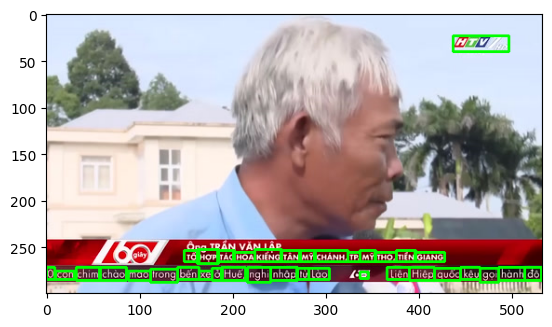

In [14]:
# height_ratio = 0.11
# y_start = int(h * (1 - height_ratio))
# y_end = y_start + int(h*0.06)
# subtitle_region = img[y_start:y_end, :]
# plt.imshow(subtitle_ref)


AttributeError: 'str' object has no attribute 'shape'

In [ ]:
# paths = ['/kaggle/input/lucifer-kf1/_output_/lucifer-kf1/L21_V017/16730.jpg']
# imgs = [cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB) for path in paths]
# img_to_det, img_to_rec = proc_batch(imgs)
# plt.imshow(img_to_det[0])